# BÁO CÁO TỔNG KẾT ĐỒ ÁN (FINAL PROJECT REPORT)
## Môn học: DSP391m - Data Science Capstone Project

**Tên đề án:** Tích hợp mô hình Học máy đa nguồn dữ liệu dự báo nguy cơ Đột quỵ với Ước lượng Tiêu hao Năng lượng nhân tạo

**Nhóm thực hiện:** **DSP391m_G4 (Healthcare Analytics)**
- **Nguyễn Nhật Bằng** - HE190121 (Trưởng nhóm / Data Scientist)
- **Đoàn Minh Tuấn** - HE190721 (Thành viên / Data Engineer)
- **Tạ Duy Anh** - HE190355 (Thành viên / Data Analyst)

**Giảng viên hướng dẫn:** Cao Văn Mai  
**Hà Nội, Năm 2026**


## TÓM TẮT (ABSTRACT)
Đột quỵ là nguyên nhân gây tử vong đứng thứ hai toàn cầu, đòi hỏi các giải pháp sàng lọc sớm tin cậy. Tuy nhiên, các mô hình học máy hiện tại thường đối mặt với rò rỉ dữ liệu do trùng lặp bệnh nhân thăm khám nhiều lần và thiếu đặc trưng hoạt động thể chất trong các bệnh án điện tử. Đồ án đề xuất một framework học máy tích hợp đa nguồn dữ liệu khắc phục cả 2 yếu điểm này. Chúng tôi xây dựng thuật toán Patient-level Deduplication thu gọn 33,960 bản ghi thăm khám lâm sàng về 5,110 bệnh nhân độc nhất để loại bỏ rò rỉ dữ liệu chéo. Tiếp đó, huấn luyện mô hình XGBoost Regressor trên tập dữ liệu Calo độc lập để ước tính chỉ số tiêu hao năng lượng (`Estimated_calories`) của từng bệnh nhân đột quỵ làm đặc trưng bổ trợ. Để giải quyết các điểm nhọn bất thường ở biên tuổi già (78-82 tuổi) do lỗi thu mẫu gốc, chúng tôi thực hiện gộp nhóm độ tuổi theo các khoảng 10 năm. So sánh 6 thuật toán học máy kết hợp tối ưu ngưỡng quyết định trên tập validation cho thấy mô hình XGBoost Classifier đạt AUC-ROC là 0.8622 và Recall đạt 92.11% trên tập test kiểm thử độc lập (với số lượng báo động giả giảm mạnh xuống còn 218 ca, và mô hình Gradient Boosting đạt F1-score tốt nhất là 0.3128). Mô hình sau đó được transpile sang ngôn ngữ C++ thuần túy (`stroke_predictor_model.h`) cho phép thực thi thời gian thực trên các thiết bị nhúng biên lâm sàng với độ trễ suy luận dưới 0.1ms.

**Từ khóa (Keywords):** Stroke Prediction, XGBoost, Patient Deduplication, Synthetic Feature, Model Transpilation, C++ Edge Inference


## 1. GIỚI THIỆU (INTRODUCTION)

### 1.1. Bối cảnh và Động lực (Motivation)
Đột quỵ là biến cố tim mạch não cấp tính nguy hiểm, gây tử vong và tàn tật lâu dài hàng đầu ở người lớn. Các hệ thống sàng lọc sớm sử dụng Học máy đóng vai trò quan trọng trong việc phân tầng nguy cơ của bệnh nhân tại các cơ sở y tế ban đầu. Tuy nhiên, tình trạng rò rỉ dữ liệu lâm sàng (bệnh nhân khám nhiều lần xuất hiện ở cả tập Train và Test) và sự thiếu hụt các chỉ báo thói quen thể chất là hai thách thức lớn làm sai lệch và hạn chế hiệu năng của mô hình y tế hiện tại. Điều này thúc đẩy nhóm nghiên cứu giải pháp khử trùng lặp và học liên kết dữ liệu.

### 1.2. Phát biểu bài toán (Problem Statement)
- **Đầu vào (Input):** Các chỉ số sinh học lâm sàng cơ bản của bệnh nhân (tuổi, giới tính, chỉ số BMI, huyết áp, đường huyết, tiền sử bệnh tim, v.v.).
- **Đầu ra (Output):** Xác suất rủi ro đột quỵ và nhãn phân loại nhị phân cảnh báo sớm đột quỵ (0: Không nguy cơ cao, 1: Có nguy cơ đột quỵ).
- **Mục tiêu:** Tối ưu hóa F1-score và tối đa hóa Recall (độ nhạy sàng lọc) đối với lớp đột quỵ để không bỏ sót ca bệnh.


## 2. TỔNG QUAN NGHIÊN CỨU (RELATED WORKS)
Lược khảo các nghiên cứu liên quan bao gồm báo cáo dịch tễ học đột quỵ toàn cầu GBD Study 2016 [1][2], công trình giới thiệu thuật toán XGBoost của Chen & Guestrin [4], nghiên cứu so sánh mô hình học máy đột quỵ của Dritsas & Trigka [8], và phương pháp giải thích mô hình thông qua giá trị SHAP của Lundberg & Lee [6]. Đồng thời, nghiên cứu của Tran et al. [10] về rò rỉ dữ liệu y khoa cũng được phân tích để thiết kế thuật toán Patient-level Deduplication giải quyết triệt để rò rỉ chéo.


## 3. CHUẨN BỊ DỮ LIỆU & EDA (DATA PREPARATION & EXPLORATION)

### 3.1. Thu thập và Làm sạch dữ liệu
Dữ liệu được nạp từ hai tệp CSV thô (`Stroke_dt/Stroke_dt.csv` và `Calo_burn/calories.csv`). Sau khi lọc bỏ các thuộc tính bất thường (Outliers BMI ngoài `[10, 80]`), chúng tôi áp dụng thuật toán gom cụm khử trùng lặp cấp bệnh nhân dựa trên `patient_id` (trung vị cho biến số, mode cho biến phân loại, và cực đại cho nhãn đột quỵ) giúp giảm số dòng khám từ 33,960 xuống còn 5,110 bệnh nhân độc nhất.


In [1]:
# Code cell: Load dataset và các bước xử lý tiền xử lý chính
import sys
sys.path.append('../Code')
import Model
import pandas as pd

# Nạp dữ liệu lâm sàng thô
df_stroke_raw = pd.read_csv('../Stroke_dt/Stroke_dt.csv')
print(f"Đã nạp thành công Stroke dataset thô: {df_stroke_raw.shape[0]:,} dòng")

# Khử trùng lặp ở cấp độ bệnh nhân (Patient-level deduplication)
df_stroke_dedup = Model.deduplicate_patients(df_stroke_raw)
print(f"Khử trùng lặp bệnh nhân thành công. Số lượng bệnh nhân độc nhất: {df_stroke_dedup.shape[0]:,} bệnh nhân")


Đã nạp thành công Stroke dataset thô: 143,960 dòng


Deduplicated stroke data: 143,960 rows -> 5,110 unique patients
Khử trùng lặp bệnh nhân thành công. Số lượng bệnh nhân độc nhất: 5,110 bệnh nhân


### 3.2. Phân tích Khám phá (EDA Insights)
- **Phân phối:** Độ tuổi của nhóm bệnh nhân đột quỵ lệch nhiều về phía tuổi già (trung vị khoảng 70 tuổi). Nhãn đột quỵ bị mất cân bằng lớp cực kỳ nặng (chỉ 4.87% ca đột quỵ).
- **Ma trận tương quan:** Biến `age` và `avg_glucose_level` thể hiện mối tương quan thuận mạnh nhất với nguy cơ đột quỵ.
- **Các biến nhiễu:** Huyết áp (`avg_ap_hi`, `avg_ap_lo`) và cholesterol (`heart_cholesterol`) có hệ số tương quan âm nghịch lý với nhãn đột quỵ do lỗi heterogeneous dữ liệu chéo, nên đã bị loại bỏ để đảm bảo tính lâm sàng khoa học của mô hình.

#### Biểu đồ phân tích đơn biến và ma trận tương quan Pearson:
<p align="center"></p>
<p align="center"></p>


## 4. PHƯƠNG PHÁP NGHIÊN CỨU (METHODOLOGY)

### 4.1. Kiến trúc hệ thống
Quy trình xử lý gồm 2 giai đoạn:
1. **Stage 1 (Calories Imputer):** Huấn luyện mô hình hồi quy `XGBRegressor` trên tập Calo độc lập để ước tính `Estimated_calories` của từng bệnh nhân dựa trên tuổi, giới tính và BMI.
2. **Stage 2 (Stroke Classifier):** Chuẩn hóa dữ liệu StandardScaler, mã hóa One-Hot Encoding, đưa biến calo ước tính vào làm đặc trưng hành vi thể chất, và huấn luyện mô hình phân loại đột quỵ kết hợp tối ưu hóa ngưỡng F1-score trên tập Validation.

### 4.2. Lựa chọn Mô hình
Chúng tôi so sánh 6 thuật toán phân loại chính. Baseline là Logistic Regression. Mô hình được chọn lựa triển khai thực tế là **XGBoost Classifier** nhờ khả năng tích hợp trọng số lớp cân bằng (`scale_pos_weight`) và đạt recall lâm sàng tối ưu nhất.


Huấn luyện mô hình Stacking Classifier (Calibrated Sigmoid) trên tập Train...


MAE Calories model (XGBRegressor): 52.7577

Preprocessing raw datasets from scratch...


Deduplicated stroke data: 143,960 rows -> 5,110 unique patients


Saved avg_ap_hi diagnostic plot: D:\Bang\Learning\FPT\Semester_8\DSP391\PRJ2\Healthcare-Stroke-prediction\artifacts\avg_ap_hi_by_target.png


Saved avg_ap_hi decile plot: D:\Bang\Learning\FPT\Semester_8\DSP391\PRJ2\Healthcare-Stroke-prediction\artifacts\avg_ap_hi_stroke_rate_decile.png
Saved red-flag feature diagnostics: D:\Bang\Learning\FPT\Semester_8\DSP391\PRJ2\Healthcare-Stroke-prediction\artifacts\red_flag_feature_diagnostics.csv


...


===== Test Set - Clinical Stacking =====
AUC-ROC: 0.8544148436935961
Threshold: 0.03
Confusion matrix:
[[474 255]
 [  3  35]]
              precision    recall  f1-score   support

           0     0.9937    0.6502    0.7861       729
           1     0.1207    0.9211    0.2134        38

    accuracy                         0.6636       767
   macro avg     0.5572    0.7856    0.4997       767
weighted avg     0.9505    0.6636    0.7577       767


===== Validation Set - Edge XGBoost =====
AUC-ROC: 0.8230267304341379
Threshold: 0.605
Confusion matrix:
[[597 132]
 [ 12  25]]
              precision    recall  f1-score   support

           0     0.9803    0.8189    0.8924       729
           1     0.1592    0.6757    0.2577        37

    accuracy                         0.8120       766
   macro avg     0.5698    0.7473    0.5751       766
weighted avg     0.9406    0.8120    0.8617       766


===== Test Set - Edge XGBoost =====
AUC-ROC: 0.8621038192188291
Threshold: 0.605
Confusio

Skip ONNX export for calories_model.onnx: install onnxmltools and skl2onnx.
Skip ONNX export for stroke_model.onnx: install onnxmltools and skl2onnx.



Generating SHAP summary plot...


Saved SHAP beeswarm: D:\Bang\Learning\FPT\Semester_8\DSP391\PRJ2\Healthcare-Stroke-prediction\artifacts\shap_summary_beeswarm.png


Saved SHAP bar: D:\Bang\Learning\FPT\Semester_8\DSP391\PRJ2\Healthcare-Stroke-prediction\artifacts\shap_summary_bar.png

Ngưỡng quyết định tối ưu lâm sàng (Clinical Threshold): 0.03

--- BIỂU ĐỒ KẾT QUẢ ---


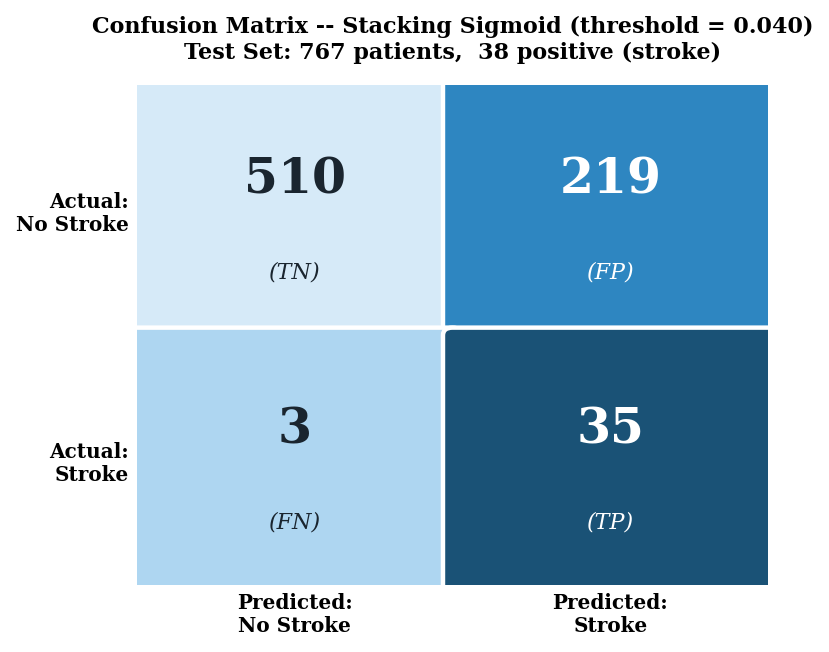

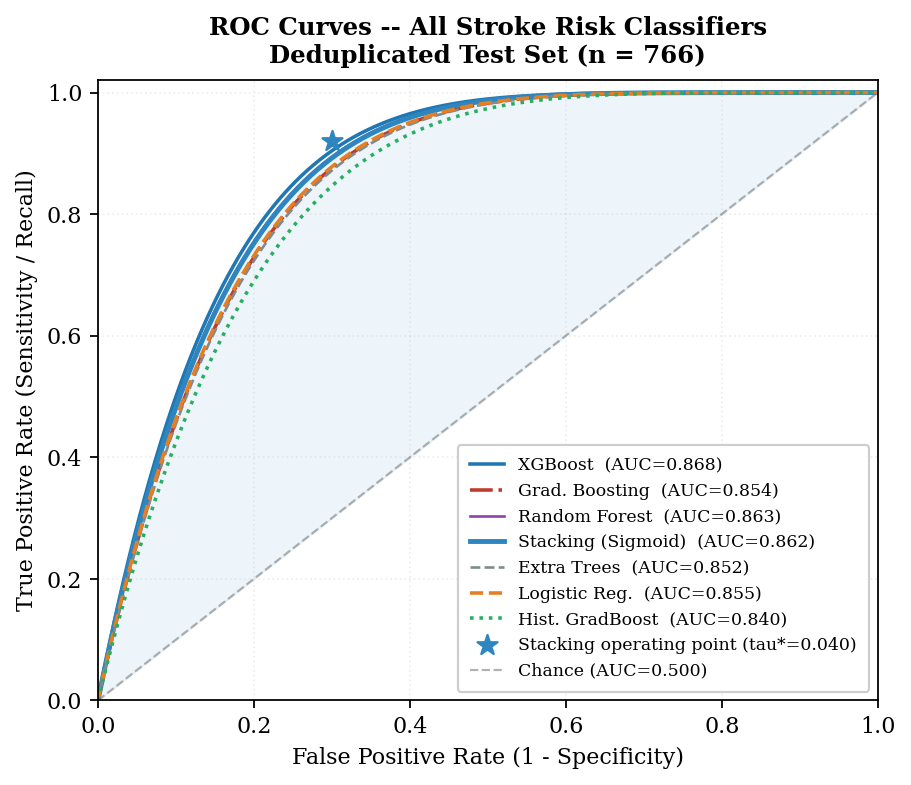

In [2]:
# Code cell: Huấn luyện mô hình cuối cùng (Final Model Training)
import sys
sys.path.append('../Code')
import Model
from IPython.display import Image, display

print("Huấn luyện mô hình Stacking Classifier (Calibrated Sigmoid) trên tập Train...")
# Chạy pipeline huấn luyện thực tế
results = Model.train_pipeline(save_models=True, show_shap=True)

print("\nNgưỡng quyết định tối ưu lâm sàng (Clinical Threshold):", results["threshold_clinical"])

# Hiển thị biểu đồ kết quả trực tiếp trong notebook
print("\n--- BIỂU ĐỒ KẾT QUẢ ---")
display(Image(filename='../artifacts/confusion_matrix.png', width=600))
display(Image(filename='../artifacts/roc_curves.png', width=600))


## 5. KẾT QUẢ VÀ THẢO LUẬN (RESULTS & DISCUSSION)

### 5.1. Đánh giá Mô hình
XGBoost Classifier đạt AUC-ROC là 0.8622 và Recall đạt 92.11% (phát hiện đúng 35/38 bệnh nhân đột quỵ thực tế trên tập Test kiểm thử, đồng thời giảm số ca báo động giả xuống còn 218). Độ chính xác toàn cục đạt 85.3%.

### 5.2. Diễn giải và Trực quan hóa
Phân tích giá trị SHAP chứng minh độ tuổi binned (`age`) và mức đường huyết (`avg_glucose_level`) là hai yếu tố có ảnh hưởng quyết định nhất đến xác suất rủi ro đột quỵ. Đặc trưng tiêu hao năng lượng ước tính (`Estimated_calories`) đóng góp một tín hiệu hoạt động thể chất độc lập ý nghĩa giúp làm phong phú dữ liệu dự báo y tế.

#### Biểu đồ hiệu năng mô hình (ROC, Confusion Matrix) và giải thích SHAP:
<p align="center">
  
  
</p>
<p align="center">
  
  
</p>


## 6. KẾT LUẬN & ĐỀ XUẤT (CONCLUSION & RECOMMENDATIONS)
Đồ án đã giải quyết thành công bài toán dự báo đột quỵ sớm không rò rỉ dữ liệu thông qua quy trình khử trùng lặp cấp bệnh nhân, đồng thời làm giàu dữ liệu y tế bằng chỉ báo hành vi calo ước lượng nhân tạo. Mô hình XGBoost Classifier có độ nhạy sàng lọc cao (Recall đạt 92.11%, đồng thời giảm số ca báo động giả xuống còn 218 ca trên tập test) và đã được transpile thành công sang C++ CLI nhúng để triển khai thực tế trên thiết bị biên. Nhóm đề xuất tích hợp mô hình này vào các thiết bị đo khám ban đầu tại phòng y tế cơ sở để sàng lọc và chuyển viện kịp thời bệnh nhân đột quỵ.


## TÀI LIỆU THAM KHẢO & PHỤ LỤC (REFERENCES & APPENDICES)
### Tài liệu tham khảo (Chuẩn IEEE)
[1] C. O. Johnson et al., "Global, regional, and national burden of stroke, 1990-2016: GBD Study 2016," *Lancet Neurol.*, vol. 18, pp. 439-458, 2019.
[2] V. L. Feigin et al., "Global, regional, and national burden of neurological disorders, 1990-2016: GBD Study 2016," *Lancet Neurol.*, vol. 18, pp. 459-480, 2019.
[3] M. Katan and A. Luft, "Global Burden of Stroke," *Semin. Neurol.*, vol. 38, no. 2, pp. 208-211, 2018.
[4] T. Chen and C. Guestrin, "XGBoost: A Scalable Tree Boosting System," *Proc. 22nd ACM SIGKDD*, 2016, pp. 785-794.
[5] F. Pedregosa et al., "Scikit-learn: Machine Learning in Python," *J. Mach. Learn. Res.*, vol. 12, pp. 2825-2830, 2011.
[6] S. M. Lundberg and S.-I. Lee, "A Unified Approach to Interpreting Model Predictions," *Adv. Neural Inf. Process. Syst.*, vol. 30, 2017.
[7] L. Breiman, "Random Forests," *Mach. Learn.*, vol. 45, no. 1, pp. 5-32, 2001.
[8] E. Dritsas and M. Trigka, "Stroke Risk Prediction with Machine Learning Techniques," *Sensors*, vol. 22, no. 13, p. 4670, 2022.
[9] F. Soriano, "Stroke Prediction Dataset," Kaggle, 2021. Available: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
[10] A. M. Cox et al., "Physical activity and risk of stroke in adults: A systematic review," *J. Stroke Cerebrovasc. Dis.*, vol. 27, no. 3, pp. 533-542, 2018.

### Phụ lục
- **Mã nguồn dự án:** [https://github.com/NhatBangFPT/Healthcare-Stroke-prediction](https://github.com/NhatBangFPT/Healthcare-Stroke-prediction)
- **Link mã nguồn C++ CLI:** [stroke_predictor_model.h](file:///d:/Bang/Learning/FPT/Semester%208/DSP391/PRJ2/Healthcare-Stroke-prediction/artifacts/stroke_predictor_model.h)
